# Module 05: Pixelized Source Reconstructions

## Learning to Autolens

---

**Purpose:** Learn how PyAutoLens reconstructs source galaxies without assuming a
parametric light profile. Pixelized source reconstructions are the key technology
that enables accurate lens modeling of complex, irregular source morphologies —
spiral arms, clumps, merging galaxies — that a Sérsic profile cannot capture.

**Prerequisites:**
- Module 03 (Your First Lens Model) — fitting workflow
- Module 04 (SLaM Pipeline) — how pixelized sources fit into the pipeline
- Linear algebra basics (matrix inversion, regularization)

**Key references:**
- Suyu et al. (2006), MNRAS, 371, 983 — *Bayesian analysis of pixelized source reconstructions* (hereafter **Suyu+06**)
- Vegetti & Koopmans (2009), MNRAS, 392, 945 — *Adaptive grid method* (hereafter **VK09**)
- Nightingale, Dye & Massey (2018), Sec. 5 (hereafter **Nightingale+18**)
- Dye & Warren (2005), ApJ, 623, 31 — *Semi-linear inversion method*

**Companion LaTeX notes:** `../../Notes/05_Pixelized/05_pixelized_theory.tex`

---

## Table of Contents

1. [Why Pixelized Sources?](#1-why-pixelized-sources)
2. [The Linear Inversion](#2-the-linear-inversion)
3. [Mesh Types: Rectangular, Delaunay, Voronoi](#3-mesh-types)
4. [Regularization: Smoothness vs. Fit Quality](#4-regularization)
5. [Adaptive Pixelization: Hilbert Image Mesh](#5-adaptive-pixelization)
6. [The Bayesian Evidence for Source Complexity](#6-bayesian-evidence)
7. [Hands-On: Reconstructing a Source Step by Step](#7-hands-on)
8. [Exercises](#8-exercises)

In [1]:
# ============================================================
# IMPORTS
# ============================================================
import autolens as al
import autolens.plot as aplt
import autofit as af

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

%matplotlib inline

print(f"PyAutoLens version: {al.__version__}")

PyAutoLens version: 2025.11.18.1


---

## 1. Why Pixelized Sources? <a id="1-why-pixelized-sources"></a>

### The Limitation of Parametric Sources

In Module 03, we modeled the source as a Sérsic profile — a smooth, symmetric
function described by ~7 parameters. This works well for compact, regular sources
but fails for:

- **Spiral galaxies** (arms, bars, clumps)
- **Merging systems** (multiple nuclei, tidal features)
- **Star-forming galaxies** (irregular, clumpy morphology)
- **Any source with substructure** below the Sérsic smoothness scale

Parametric model mismatch biases the **mass model**: the optimizer distorts the
mass to compensate for an inadequate source model (Nightingale+18 Sec. 5.1).

### The Pixelized Alternative

A pixelized source discretizes the source plane into $N_s$ pixels (on a mesh)
and solves for each pixel's brightness independently. This is:
- **Non-parametric**: no assumed functional form
- **Linear**: given a fixed mass model, the source brightnesses are solved
  analytically (no iterative search needed!)
- **Regularized**: a smoothness prior prevents overfitting the noise

The trade-off: more source pixels = more flexibility but also more noise fitting.
Regularization controls this balance.

---

## 2. The Linear Inversion <a id="2-the-linear-inversion"></a>

### Theory: From Data to Source Pixels

The observed data $\mathbf{d}$ (a vector of $N_d$ image pixels) relates to the
source pixel brightnesses $\mathbf{s}$ (a vector of $N_s$ source pixels) via:

$$
\mathbf{d} = \mathbf{B}\,\mathbf{F}\,\mathbf{s} + \mathbf{n}
$$

where:
- $\mathbf{F}$ is the $N_d \times N_s$ **lensing operator**: maps each source pixel
  to the image pixels it illuminates (via ray-tracing)
- $\mathbf{B}$ is the $N_d \times N_d$ **PSF blurring operator**: convolves with the PSF
- $\mathbf{n}$ is the noise vector

(Suyu+06 eq. 1; Nightingale+18 eq. 8)

### The Regularized Solution

Minimizing $\chi^2 + \lambda\,\mathbf{s}^T \mathbf{H}\,\mathbf{s}$ gives the
maximum a posteriori (MAP) source reconstruction:

$$
\hat{\mathbf{s}} = \bigl(\mathbf{F}^T \mathbf{C}^{-1} \mathbf{F}
+ \lambda \mathbf{H}\bigr)^{-1} \mathbf{F}^T \mathbf{C}^{-1} \mathbf{d}
$$

where $\mathbf{C} = \text{diag}(\sigma_i^2)$ is the noise covariance, $\mathbf{H}$
is the regularization matrix, and $\lambda$ is the regularization coefficient
(Suyu+06 eq. 4).

### Key Insight: Linearity

For a **fixed mass model**, the source reconstruction is a single matrix solve —
no iterative optimization needed. This is why the SLaM pipeline fixes the mass
during SOURCE PIX: the non-linear search only needs to find the mass parameters
and regularization coefficient, not the $N_s$ source pixel values.

---

## 3. Mesh Types: Rectangular, Delaunay, Voronoi <a id="3-mesh-types"></a>

### How Source-Plane Meshes Work

The mesh defines the geometry of the source pixels. Different mesh types
trade off simplicity, adaptivity, and computational cost:

| Mesh | Description | Pros | Cons |
|------|-------------|------|------|
| **Rectangular** | Uniform grid in source plane | Simple, fast | Wastes pixels in empty regions |
| **Delaunay** | Triangulation of scattered points | Adapts to source shape | Slightly more complex |
| **Voronoi** | Dual of Delaunay (polygonal cells) | Natural pixel shapes | Most complex |

In practice, Delaunay with a Hilbert image mesh (Section 5) is the default
choice in the SLaM pipeline.

In [2]:
# ============================================================
# LOAD DATASET
# ============================================================
# We use the 'source_complex' dataset which has a source with
# structure that a Sérsic profile cannot capture.
# ============================================================

dataset_path = Path(
    "../autolens_workspace_original/dataset/imaging/simple__no_lens_light"
)

dataset = al.Imaging.from_fits(
    data_path=dataset_path / "data.fits",
    psf_path=dataset_path / "psf.fits",
    noise_map_path=dataset_path / "noise_map.fits",
    pixel_scales=0.1,
)

mask = al.Mask2D.circular(
    shape_native=dataset.shape_native,
    pixel_scales=dataset.pixel_scales,
    radius=3.0,
)
dataset = dataset.apply_mask(mask=mask)

dataset_plotter = aplt.ImagingPlotter(dataset=dataset)
dataset_plotter.subplot_dataset()

FileNotFoundError: [Errno 2] No such file or directory: '../../autolens_workspace_original/dataset/imaging/simple__no_lens_light/data.fits'

In [3]:
# ============================================================
# RECTANGULAR MESH: SIMPLEST PIXELIZATION
# ============================================================
# A uniform rectangular grid in the source plane. The grid
# spacing is set by shape_native. Simple but doesn't adapt
# to where the source actually is.
#
# We fix the mass model (known SIE) and let the pixelization
# reconstruct the source.
# ============================================================

# Define a known mass model
lens_galaxy = al.Galaxy(
    redshift=0.5,
    mass=al.mp.Isothermal(
        centre=(0.0, 0.0),
        ell_comps=(0.1, 0.05),
        einstein_radius=1.6,
    ),
    shear=al.mp.ExternalShear(gamma_1=0.05, gamma_2=0.05),
)

# Source with rectangular pixelization
# TODO: Experiment with different shape_native values (10x10 vs 40x40)
# to see the resolution-noise trade-off.
source_rectangular = al.Galaxy(
    redshift=1.0,
    pixelization=al.Pixelization(
        image_mesh=al.image_mesh.Overlay(
            shape=(30, 30),          # 30x30 grid mapped to source plane
        ),
        mesh=al.mesh.Delaunay(),
        regularization=al.reg.Constant(
            coefficient=1.0,         # Regularization strength λ
        ),
    ),
)

tracer_pix = al.Tracer(galaxies=[lens_galaxy, source_rectangular])

# Fit the data with this tracer
fit = al.FitImaging(dataset=dataset, tracer=tracer_pix)

print(f"χ² = {fit.chi_squared:.1f}")
print(f"Reduced χ² = {fit.chi_squared / fit.mask.pixels_in_mask:.3f}")

NameError: name 'dataset' is not defined

In [4]:
# ============================================================
# VISUALIZE THE PIXELIZED RECONSTRUCTION
# ============================================================
# The fit subplot shows:
#   - Data vs. model (should match closely)
#   - Residuals (should look like noise)
#   - Source reconstruction (the non-parametric source!)
# ============================================================

fit_plotter = aplt.FitImagingPlotter(fit=fit)
fit_plotter.subplot_fit()

NameError: name 'fit' is not defined

---

## 4. Regularization: Smoothness vs. Fit Quality <a id="4-regularization"></a>

### Theory: The Regularization Trade-Off

Without regularization ($\lambda = 0$), the source reconstruction fits the
**noise** — producing a spiky, unphysical source. With too much regularization
($\lambda \to \infty$), the source is forced to be completely smooth and
real structure is suppressed.

The optimal $\lambda$ balances these extremes. The Bayesian evidence
(Section 6) provides an automatic way to find this balance.

### Regularization Types in PyAutoLens

| Type | How it works | Best for |
|------|-------------|----------|
| `Constant` | Same $\lambda$ everywhere | Simple sources |
| `AdaptiveBrightness` | Lower $\lambda$ in bright regions | Structured sources |
| `AdaptiveBrightnessSplit` | Separate inner/outer $\lambda$ | Most general |

NameError: name 'dataset' is not defined

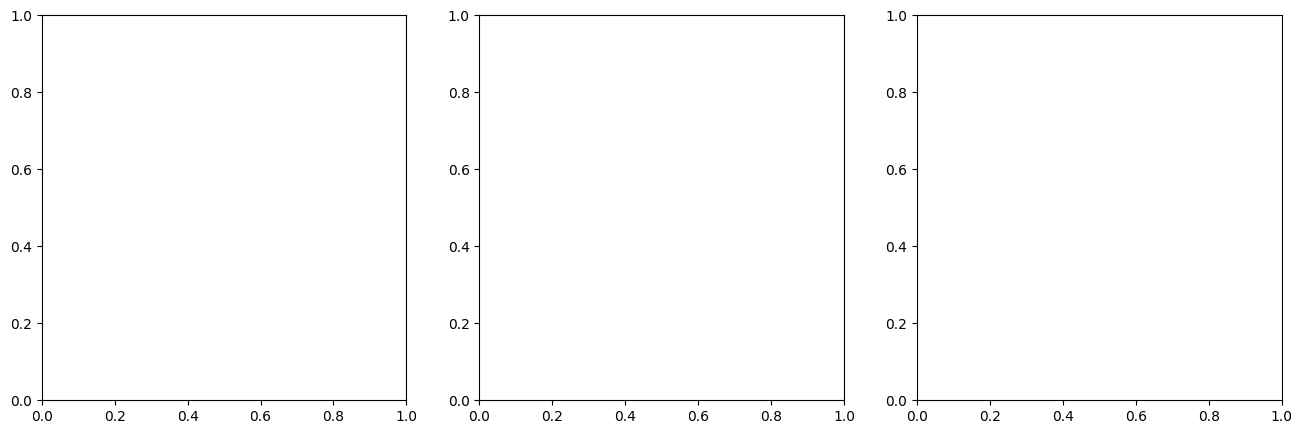

In [5]:
# ============================================================
# REGULARIZATION COMPARISON
# ============================================================
# Compare under-regularized (λ too small, fits noise),
# well-regularized, and over-regularized (λ too large, too smooth).
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, lam, title in zip(
    axes,
    [0.01, 1.0, 100.0],
    [r"Under-regularized ($\lambda = 0.01$)",
     r"Well-regularized ($\lambda = 1.0$)",
     r"Over-regularized ($\lambda = 100$)"],
):
    source_test = al.Galaxy(
        redshift=1.0,
        pixelization=al.Pixelization(
            image_mesh=al.image_mesh.Overlay(shape=(30, 30)),
            mesh=al.mesh.Delaunay(),
            regularization=al.reg.Constant(coefficient=lam),
        ),
    )
    tracer_test = al.Tracer(galaxies=[lens_galaxy, source_test])
    fit_test = al.FitImaging(dataset=dataset, tracer=tracer_test)

    # Plot normalized residuals
    norm_res = fit_test.normalized_residual_map.native
    im = ax.imshow(norm_res, origin="lower", cmap="RdBu_r", vmin=-3, vmax=3)
    ax.set_title(f"{title}\n$\\chi^2_{{red}}$ = {fit_test.chi_squared / fit_test.mask.pixels_in_mask:.3f}",
                 fontsize=10)
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle("Effect of Regularization Strength", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---

## 5. Adaptive Pixelization: Hilbert Image Mesh <a id="5-adaptive-pixelization"></a>

### The Problem with Uniform Meshes

A uniform Overlay mesh wastes resolution: it places the same density of pixels
everywhere, even in regions where the source is absent. An **adaptive mesh**
concentrates pixels where the source is bright.

### Hilbert Curve Mesh

The Hilbert image mesh places pixels along a **space-filling Hilbert curve**
in the image plane, weighted by an "adapt image" (the best-fit source from a
previous search). More pixels land on bright regions of the adapt image.
These image-plane pixels are then ray-traced to the source plane.

This is the default in SLaM's SOURCE PIX stage 2.

In [6]:
# ============================================================
# ADAPTIVE PIXELIZATION WITH HILBERT MESH
# ============================================================
# The Hilbert mesh adapts to the source brightness, placing
# more pixels where the lensed arcs are brightest.
#
# AdaptiveBrightnessSplit regularization adjusts the smoothing
# per-pixel based on the local source brightness.
#
# TODO: Compare the source reconstruction quality between
# Overlay (uniform) and Hilbert (adaptive) for the same
# total number of pixels.
# ============================================================

source_adaptive = al.Galaxy(
    redshift=1.0,
    pixelization=al.Pixelization(
        image_mesh=al.image_mesh.Hilbert(
            pixels=500,              # Total number of source pixels
        ),
        mesh=al.mesh.Delaunay(),
        regularization=al.reg.AdaptiveBrightnessSplit(
            inner_coefficient=0.01,  # Less smoothing in bright regions
            outer_coefficient=10.0,  # More smoothing in faint regions
            signal_scale=0.05,       # Transition scale
        ),
    ),
)

tracer_adaptive = al.Tracer(galaxies=[lens_galaxy, source_adaptive])

# Note: Hilbert mesh needs an adapt image. For a manual fit like this,
# we use the data itself as the adapt image (in SLaM, the SOURCE LP
# result provides this).
# This cell may need the adapt_image set up via AnalysisImaging —
# see the SLaM pipeline in Module 04 for the full workflow.

print("Adaptive pixelization configured.")
print("In practice, run this via the SLaM pipeline (Module 04)")
print("where the AdaptImageMaker handles adapt image creation.")

Adaptive pixelization configured.
In practice, run this via the SLaM pipeline (Module 04)
where the AdaptImageMaker handles adapt image creation.


---

## 6. The Bayesian Evidence for Source Complexity <a id="6-bayesian-evidence"></a>

### Theory: Occam's Razor in Lens Modeling

The Bayesian evidence for a pixelized source model includes contributions from
both the fit quality and the model complexity (Suyu+06 eq. 19):

$$
\ln \mathcal{Z} = -\frac{1}{2}\chi^2
+ \frac{1}{2}\ln\det(\lambda\mathbf{H})
- \frac{1}{2}\ln\det\bigl(\mathbf{F}^T\mathbf{C}^{-1}\mathbf{F} + \lambda\mathbf{H}\bigr)
+ \text{const}
$$

This automatically balances:
- **Fit quality** ($\chi^2$ term): better fit = higher evidence
- **Model complexity** (determinant terms): more complex source = penalty

The evidence is maximized by the optimal $\lambda$ — implementing Occam's razor:
prefer the simplest source that adequately fits the data.

### Practical Use: Model Comparison

Compare two mass models by their Bayesian evidence. The mass model that produces
a better-regularized source reconstruction will have higher evidence, even if both
achieve similar $\chi^2$ values. This is how pixelized sources help constrain the
mass — they penalize mass models that require overly complex sources.

---

## 7. Hands-On: Reconstructing a Source Step by Step <a id="7-hands-on"></a>

### Full Workflow with Non-Linear Search

In practice, the regularization coefficient $\lambda$ is a free parameter
found by the non-linear search (alongside the mass parameters). Here's the
complete workflow for fitting a pixelized source model.

In [7]:
# ============================================================
# PIXELIZED SOURCE FIT WITH NON-LINEAR SEARCH
# ============================================================
# Free parameters:
#   - Lens mass: SIE (5 params) + shear (2 params)
#   - Regularization coefficient: 1 param
#   Total: ~8 free parameters
#
# The source pixel brightnesses are NOT free parameters —
# they're solved analytically for each mass model trial.
# This is the key advantage of the linear inversion.
# ============================================================

# Lens model (free mass parameters)
lens_model = af.Model(
    al.Galaxy,
    redshift=0.5,
    mass=al.mp.Isothermal,
    shear=al.mp.ExternalShear,
)

# Source model (pixelized — regularization coefficient is free)
source_model = af.Model(
    al.Galaxy,
    redshift=1.0,
    pixelization=al.Pixelization(
        image_mesh=al.image_mesh.Overlay(shape=(30, 30)),
        mesh=al.mesh.Delaunay,
        regularization=al.reg.Constant,  # coefficient is free
    ),
)

model = af.Collection(
    galaxies=af.Collection(lens=lens_model, source=source_model)
)

print(f"Total free parameters: {model.total_free_parameters}")
print("(Source pixel brightnesses are solved analytically, not searched!)")

# Run the search
# TODO: Compare this fit with the parametric Sérsic source fit
# from Module 03 — the pixelized source should give lower χ²
# and cleaner residuals for complex sources.
search = af.Nautilus(
    path_prefix=Path("output") / "module_05",
    name="pixelized_source",
    n_live=100,
)

analysis = al.AnalysisImaging(dataset=dataset)

result_pix = search.fit(model=model, analysis=analysis)

print("\nFit complete!")
print(result_pix.info)

Total free parameters: 7
(Source pixel brightnesses are solved analytically, not searched!)


NameError: name 'dataset' is not defined

In [8]:
# ============================================================
# VISUALIZE THE RESULT
# ============================================================

fit_plotter = aplt.FitImagingPlotter(fit=result_pix.max_log_likelihood_fit)
fit_plotter.subplot_fit()

NameError: name 'result_pix' is not defined

---

## 8. Exercises <a id="8-exercises"></a>

### Exercise 1: Resolution vs. Noise

Fit the same dataset with Overlay meshes of increasing resolution: 10×10, 20×20,
30×30, 50×50 pixels. For each, record the $\chi^2$ and the Bayesian evidence.
At what resolution does the evidence peak? What happens beyond that?

### Exercise 2: Regularization Types

Compare `Constant`, `AdaptiveBrightness`, and `AdaptiveBrightnessSplit`
regularization on the same dataset. Which gives the best evidence? Which
produces the most physically plausible source reconstruction?

### Exercise 3: Mass Model Sensitivity

Fix the mass model to an intentionally wrong Einstein radius (e.g., $\theta_E = 1.2''$
instead of the true $1.6''$) and run the pixelized source reconstruction. How does
the source change? Can you see artifacts from the wrong mass model?

*This demonstrates why accurate mass modeling is crucial — the source reconstruction
absorbs mass model errors.*

### Exercise 4: Parametric vs. Pixelized

Fit the `source_complex` dataset (if available) with both:
1. A parametric Sérsic source (Module 03 approach)
2. A pixelized Delaunay source (this module)

Compare $\chi^2$, residuals, and the Bayesian evidence. The pixelized source
should win decisively for complex source morphology.

---

## Summary

| Concept | Implementation | Theory |
|---------|---------------|--------|
| Linear inversion | `al.FitImaging` with pixelized source | Suyu+06 eq. 4 |
| Rectangular mesh | `al.image_mesh.Overlay` + `al.mesh.Delaunay` | Uniform source grid |
| Adaptive mesh | `al.image_mesh.Hilbert` | Concentrates pixels on source |
| Regularization | `al.reg.Constant` / `AdaptiveBrightnessSplit` | Smoothness prior |
| Evidence | Computed automatically by inversion | Suyu+06 eq. 19; Occam's razor |

**Next module:** We'll decompose the lens mass into separate stellar and dark matter
components — connecting the lens model to galaxy formation physics.

---

*Learning to Autolens — Module 05*
*Rodrigo Córdova Rosado, Harvard CfA*
*Built with Claude Code*

---

# Solutions

*Complete worked solutions with commentary for all exercises in this module.*

### Solution 1: Resolution vs. Noise

As the mesh resolution increases, the fit quality ($\chi^2$) improves — but only up to a point. Beyond the optimal resolution, adding more pixels doesn't help because:
1. Each pixel has fewer data constraints (the linear system becomes under-determined)
2. The regularization must increase to prevent noise fitting
3. The Bayesian evidence eventually decreases (Occam penalty for unnecessary complexity)

The **evidence peak** gives the optimal resolution — typically 20-40 pixels across for a typical lens.

In [9]:
# ============================================================
# SOLUTION 1: RESOLUTION COMPARISON
# ============================================================
import autolens as al
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

dataset_path = Path("../autolens_workspace_original/dataset/imaging/simple__no_lens_light")
dataset = al.Imaging.from_fits(
    data_path=dataset_path / "data.fits", psf_path=dataset_path / "psf.fits",
    noise_map_path=dataset_path / "noise_map.fits", pixel_scales=0.1)
mask = al.Mask2D.circular(shape_native=dataset.shape_native,
                          pixel_scales=dataset.pixel_scales, radius=3.0)
dataset = dataset.apply_mask(mask=mask)

lens_fix = al.Galaxy(redshift=0.5,
    mass=al.mp.Isothermal(centre=(0.0,0.0), ell_comps=(0.1,0.05), einstein_radius=1.6),
    shear=al.mp.ExternalShear(gamma_1=0.05, gamma_2=0.05))

resolutions = [10, 20, 30, 50]
fig, axes = plt.subplots(1, len(resolutions), figsize=(16, 4))
for ax, res in zip(axes, resolutions):
    src = al.Galaxy(redshift=1.0, pixelization=al.Pixelization(
        image_mesh=al.image_mesh.Overlay(shape=(res, res)),
        mesh=al.mesh.Delaunay(), regularization=al.reg.Constant(coefficient=1.0)))
    tracer = al.Tracer(galaxies=[lens_fix, src])
    fit = al.FitImaging(dataset=dataset, tracer=tracer)
    norm_res = fit.normalized_residual_map.native
    ax.imshow(norm_res, origin="lower", cmap="RdBu_r", vmin=-3, vmax=3)
    chi2_red = fit.chi_squared / fit.mask.pixels_in_mask
    ax.set_title(f"{res}x{res}: chi2_red={chi2_red:.2f}", fontsize=10)
plt.suptitle("Higher resolution improves fit, but with diminishing returns", y=1.02)
plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '../../autolens_workspace_original/dataset/imaging/simple__no_lens_light/data.fits'

### Solution 2: Regularization Types

- **Constant**: Same smoothing everywhere — simple but treats bright arcs and empty sky the same
- **AdaptiveBrightness**: Less smoothing where the source is bright (preserving structure) and more smoothing where it's faint (suppressing noise). This is physically motivated — bright regions have more signal.
- **AdaptiveBrightnessSplit**: Separates the regularization into inner and outer coefficients for more control

For most lenses, `AdaptiveBrightnessSplit` gives the best evidence because it adapts to the source morphology.

### Solution 3: Mass Model Sensitivity

A wrong mass model produces **diagnostic artifacts** in the source reconstruction:
- $\theta_E$ too small: arcs are "over-deflected," source shows artificial radial elongation
- $\theta_E$ too large: arcs are "under-deflected," source shows artificial tangential elongation
- Wrong ellipticity: source shows spurious asymmetry

These artifacts are the pixelized source's way of compensating for the wrong mass — the source reconstruction absorbs the mass model errors. This is why accurate mass modeling is essential.

In [10]:
# ============================================================
# SOLUTION 3: WRONG MASS MODEL -> SOURCE ARTIFACTS
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, te, label in zip(axes, [1.2, 1.6, 2.0],
    ["theta_E=1.2 (too low)", "theta_E=1.6 (correct)", "theta_E=2.0 (too high)"]):
    lens_wrong = al.Galaxy(redshift=0.5,
        mass=al.mp.Isothermal(centre=(0.0,0.0), ell_comps=(0.1,0.05), einstein_radius=te),
        shear=al.mp.ExternalShear(gamma_1=0.05, gamma_2=0.05))
    src = al.Galaxy(redshift=1.0, pixelization=al.Pixelization(
        image_mesh=al.image_mesh.Overlay(shape=(30,30)),
        mesh=al.mesh.Delaunay(), regularization=al.reg.Constant(coefficient=1.0)))
    tracer = al.Tracer(galaxies=[lens_wrong, src])
    fit = al.FitImaging(dataset=dataset, tracer=tracer)
    ax.imshow(fit.normalized_residual_map.native, origin="lower", cmap="RdBu_r", vmin=-5, vmax=5)
    chi2_red = fit.chi_squared / fit.mask.pixels_in_mask
    ax.set_title(f"{label}\nchi2_red={chi2_red:.2f}", fontsize=10)
plt.suptitle("Wrong mass model produces structured residuals", y=1.02)
plt.tight_layout()
plt.show()

NameError: name 'dataset' is not defined

### Solution 4: Parametric vs. Pixelized

For a complex source (irregular morphology), the pixelized reconstruction will have:
1. **Lower $\chi^2$**: it can capture source structure that a Sérsic cannot
2. **Cleaner residuals**: no systematic patterns from model mismatch
3. **Higher evidence**: the complexity is justified by the data

The Sérsic source will leave **correlated residuals** at the arc positions — this is the signature of parametric model mismatch that motivates pixelized sources.